# Merge and rename HRRC SVI Files
Current HRRC SVI files have input variables and SVI ranks for the Texas in different files.
This notebook merges the files and renames the variables to match the SVI.

## Description of Program
- program:    tu3svi2_2cv1_SetupHRRC
- task:       Clean HRRC files and rename variables
- Version:    2023-11-09
- 2023-11-29: add SVI quartiles
- 2024-04-30: Check Group Quarters Variable
- 2024-06-12: Updated data from Doug
- 2024-08-26: Update with 2020 data
- 2024-09-20: Rerun so that SVI have consistent number of significant digits
- 2025-04-08: Rerun with updated metadata file
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 2 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [1]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays
import os # For saving to path

In [2]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
geopandas version:  0.14.2


In [3]:
# Add the folder above the current notebook directory to the Python path
sys.path.append('../')

# Import the script as a module
import tu3svi2_0bv1_sourcedatautility_20240906 as my_utility

## Set Provenance 

In [4]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme_3_eq\\Text\\SVI_Analysis_Paper\\DesignSafe-Archive\\SourceData\\texasatlas_arch_tamu_edu'

In [5]:
# Store Program Name for output files to have the same name and saved in the same directory
programname = "tu3svi2_2cv3_SetupHRRC_2025-04-08"
# Make directory to save output
#if not os.path.exists(programname):
#   os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [6]:
# read in excel file
# Read in sheet with all metadata on each variable
varmetadata_df = pd.read_excel("../tu3svi2_0av3_SVIdatadictionary_2025-04-08.xlsx",
                            sheet_name="SVI_vars")
# sort by order
varmetadata_df = varmetadata_df.sort_values(by=['order'])
varmetadata_df[(varmetadata_df['SVI']=='HRRC')].tail()

,SVI,order,year,newvarname,gencat,gencatcode,comcat,comcatcode,theme,SVIcat,label,oldvarname,ACStable1v2,ACStable1v1,inverted,proportion,percent,dtype
145,HRRC,91012,2020,H202091012,Index Total,910,SVI Quartile (TX) v2,12,NaN,Index Total,SVI Quartile of SVIq,SVIp_sviq,NaN,NaN,0,0,0,str
51,HRRC,91093,2018,H201891093,Index Total,910,SVI Quartile (TX),93,NaN,Index Total,SVI Quartile of SVIr,SVIr_sviq,NaN,NaN,0,0,0,str
144,HRRC,91093,2020,H202091093,Index Total,910,SVI Quartile (TX),93,NaN,Index Total,SVI Quartile of SVIr,SVIr_sviq,NaN,NaN,0,0,0,str
53,HRRC,92021,2018,H201892021,Index Total,920,SVI HRRC Match,21,NaN,Index Total,Match Between SVIq,sviq_match,NaN,NaN,0,0,0,float
146,HRRC,92021,2020,H202092021,Index Total,920,SVI HRRC Match,21,NaN,Index Total,Match Between SVIq,sviq_match,NaN,NaN,0,0,0,float


In [7]:
data_year = 2020
svi_name = 'HRRC'
geoscales = ['Tract','BG']  # census tract and block group
files = {  'TractTX' : {'folder' : '', 
                                'inputvars' : 'HRRC_2020_TX_Tract_2024-08-26.csv'},
                    'BGTX' : {'folder' : '', 
                                'inputvars' : 'HRRC_2020_TX_BG_2024-08-26.csv'}
                }

In [8]:
dfs = {}
for file in files:
    # Set path to folder containing the files to be merged
    path = files[file]['folder']
    # Set path to input variables file
    inputvars = files[file]['inputvars']

    dfs[file] = pd.read_csv(inputvars, dtype={'GEOID' : str})

In [9]:
# rename GEOID GEOID_Tract
dfs['TractTX'] = dfs['TractTX'].rename(columns={'GEOID' : 'GEOID_Tract'})
dfs['TractTX']

,OBJECTID,COUNTYFP,GEOID_Tract,CZ,POPe,HHe,CHILDe,CHILDi,CHILDz,CHILDp,...,CIVICCAPq,SVIq,CHILDCAREc,ELDERCAREc,TRANSNEEDc,SHELTNEEDc,CIVICCAPc,SVIc,Shape__Area,Shape__Length
0,1,48029,48029181703,69,7876,2832,314,3.987,-0.797,0.197,...,1,1,1,3,2,3,2,2,4.992877e+06,10077.600523
1,2,48029,48029181704,69,6472,1892,317,4.898,-0.532,0.305,...,4,3,2,3,4,3,4,4,7.609385e+06,12785.580711
2,3,48029,48029181705,69,6167,2412,691,11.205,1.298,0.904,...,3,3,5,1,4,3,3,4,5.946768e+06,10578.466881
3,4,48029,48029181711,69,8967,2825,209,2.331,-1.277,0.081,...,1,2,1,3,3,2,1,2,4.960805e+06,9307.749500
4,5,48029,48029181712,69,4471,1309,331,7.403,0.195,0.622,...,3,3,3,4,3,2,3,3,2.235500e+06,6584.875026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6879,6892,48061,48061012700,291,5072,1215,427,8.419,0.489,0.723,...,4,2,3,2,2,3,4,2,2.452862e+08,107578.612071
6880,6893,48061,48061013203,291,2200,659,110,5.000,-0.503,0.318,...,5,5,3,2,5,5,5,5,1.337990e+06,4939.265537
6881,6894,48061,48061012508,291,4244,1186,290,6.833,0.029,0.559,...,5,3,3,3,2,3,5,3,3.089575e+07,33451.638857
6882,6895,48061,48061011903,291,2444,649,167,6.833,0.029,0.558,...,3,4,3,5,4,4,3,4,7.710787e+07,50337.334406


In [10]:
# rename GEOID GEOID_Tract
dfs['BGTX'] = dfs['BGTX'].rename(columns={'GEOID' : 'GEOID_BG'})
dfs['BGTX']

,OBJECTID,COUNTYFP,GEOID_BG,CZ,POPe,HHe,CHILDe,CHILDi,CHILDz,CHILDp,...,CIVICCAPq,SVIq,CHILDCAREc,ELDERCAREc,TRANSNEEDc,SHELTNEEDc,CIVICCAPc,SVIc,Shape__Area,Shape__Length
0,1,48001,480019501001,475.0,1640,608,104,6.341,-0.046,0.547,...,5,5,4,4,4,4,5,5,2.124466e+07,25431.426373
1,2,48001,480019501002,475.0,1901,626,256,13.467,1.353,0.906,...,4,2,4,3,2,2,3,3,3.261917e+08,108560.446051
2,3,48001,480019501003,475.0,1417,545,63,4.446,-0.419,0.383,...,1,2,3,2,2,2,1,2,3.371185e+08,93125.623506
3,4,48001,480019504011,475.0,4867,81,34,0.699,-1.155,0.116,...,3,1,2,1,1,5,3,1,2.330774e+07,28412.793615
4,5,48001,480019504021,475.0,7335,0,0,0.000,-1.292,0.000,...,2,1,1,1,1,1,2,1,1.024178e+08,72910.047498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18621,18634,48507,485079503022,506.0,198,144,0,0.000,-1.292,0.000,...,2,2,1,5,3,2,2,2,7.444344e+05,3508.480324
18622,18635,48507,485079503023,506.0,1659,572,142,8.559,0.389,0.706,...,4,3,4,3,3,1,3,3,1.534515e+06,5912.389304
18623,18636,48507,485079503024,506.0,588,303,0,0.000,-1.292,0.000,...,1,1,1,3,2,3,1,1,9.719232e+05,4410.088419
18624,18637,48507,485079503025,506.0,2197,536,98,4.461,-0.416,0.385,...,1,1,3,1,1,2,1,1,6.306705e+05,3450.571066


## Check group quarters variable
There seems to be an issue with the group quarters varible

In [11]:
# look at variables that start with GQ
GQ_vars = [col for col in dfs['TractTX'].columns if col.startswith('GQ')]
GQ_vars

['GQe', 'GQi', 'GQz', 'GQp', 'GQq']

In [12]:
# describe GQ vars
dfs['TractTX'][GQ_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
GQe,6884.0,86.517577,453.461112,0.000,0.000,0.000,20.00000,9627.000
GQi,6884.0,2.101760,9.275744,0.000,0.000,0.000,0.55600,100.000
GQz,6884.0,0.000642,1.000903,-0.226,-0.226,-0.226,-0.16600,10.565
GQp,6884.0,0.318174,0.398942,0.000,0.000,0.000,0.75025,0.997
GQq,6884.0,2.262638,1.671963,1.000,1.000,1.000,4.00000,5.000


In [13]:
dfs['TractTX'][['GEOID_Tract']+GQ_vars].head()

,GEOID_Tract,GQe,GQi,GQz,GQp,GQq
0,48029181703,103,1.308,-0.085,0.812,5
1,48029181704,10,0.155,-0.210,0.656,4
2,48029181705,0,0.000,-0.226,0.000,1
3,48029181711,8,0.089,-0.217,0.621,3
4,48029181712,121,2.706,0.066,0.886,5


In [14]:
import requests
# start data dictionary for gqpop_apidf
gqpop_apidf = {}

acs_year = '2018'
srvy = '5'
var = 'GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E'
state = '48'
county = '*'
# Set up hyperlink for Census API
api_hyperlink = ('https://api.census.gov/data/'+acs_year+'/acs/acs'+srvy+'?get='+var+
                    '&in=state:'+state+'+county:'+county+'&for=tract:*')
print("Census API data from: "+ api_hyperlink)
# Obtain Census API JSON Data
apijson = requests.get(api_hyperlink)
# Convert the requested json into pandas dataframe
gqpop_apidf['Tract'] = pd.DataFrame(columns=apijson.json()[0], data=apijson.json()[1:])

Census API data from: https://api.census.gov/data/2018/acs/acs5?get=GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E&in=state:48+county:*&for=tract:*


In [15]:
# Set up hyperlink for Census API
api_hyperlink = ('https://api.census.gov/data/'+acs_year+'/acs/acs'+srvy+'?get='+var+
                    '&in=state:'+state+'+county:'+county+'&for=block%20group:*')
print("Census API data from: "+ api_hyperlink)
# Obtain Census API JSON Data
apijson = requests.get(api_hyperlink)
# Convert the requested json into pandas dataframe
gqpop_apidf['BG'] = pd.DataFrame(columns=apijson.json()[0], data=apijson.json()[1:])

Census API data from: https://api.census.gov/data/2018/acs/acs5?get=GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E&in=state:48+county:*&for=block%20group:*


In [16]:
gqpop_apidf['Tract'].head()

,GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E,state,county,tract
0,1400000US48135002200,3288,3288,8,8,48,135,002200
1,1400000US48061012800,5345,5345,0,0,48,061,012800
2,1400000US48061013204,2240,2240,0,0,48,061,013204
3,1400000US48061013307,1782,1782,0,0,48,061,013307
4,1400000US48061013902,4197,4197,0,0,48,061,013902


In [17]:
gqpop_apidf['BG'].head()

,GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E,state,county,tract,block group
0,1500000US482012537002,1384,1384,0,None,48,201,253700,2
1,1500000US481130190243,1043,1043,0,None,48,113,019024,3
2,1500000US484391132201,3181,3181,0,None,48,439,113220,1
3,1500000US481210216331,1375,1375,0,None,48,121,021633,1
4,1500000US481210215263,966,966,0,None,48,121,021526,3


In [18]:
def clean_api_data(api_df, hrrc_df, GEOID_merge = 'GEOID_Tract'):
    ### 2.1 Set the variable type
    api_df["B09019_001E"] = api_df["B09019_001E"].astype(int)
    api_df["B01001_001E"] = api_df["B01001_001E"].astype(int)
    api_df["B09019_038E"] = api_df["B09019_038E"].astype(int)

    # Block group B26001_001E is NONE type
    if GEOID_merge == 'GEOID_Tract':
        api_df["B26001_001E"] = api_df["B26001_001E"].astype(int)

    # run correlation between B01001_001E and B09019_001E
    corr1 = api_df['B01001_001E'].corr(api_df['B09019_001E'])
    # run correlation between B26001_001E and B09019_038E
    corr2 = api_df['B26001_001E'].corr(api_df['B09019_038E'])
    print(corr1)
    print(corr2)

    if GEOID_merge == 'GEOID_Tract':
        # create GEOID_Tract - drop 1400000US
        api_df[GEOID_merge] = api_df['GEO_ID'].str.replace('1400000US','')
    elif GEOID_merge == 'GEOID_BG':
        api_df[GEOID_merge] = api_df['GEO_ID'].str.replace('1500000US','')

    # merge with HHRC
    merged_df = pd.merge(hrrc_df[[GEOID_merge]+GQ_vars], 
                            api_df, 
                            on=GEOID_merge, 
                            how='left')

    return merged_df

check_gqpop_merge_df = {}
# check function
check_gqpop_merge_df['Tract'] = clean_api_data(gqpop_apidf['Tract'], dfs['TractTX'], GEOID_merge = 'GEOID_Tract')
check_gqpop_merge_df['BG'] = clean_api_data(gqpop_apidf['BG'], dfs['BGTX'], GEOID_merge = 'GEOID_BG')

0.9999999999999999
1.0
1.0
nan


In [19]:
check_gqpop_merge_df['Tract'].head()

,GEOID_Tract,GQe,GQi,GQz,GQp,GQq,GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E,state,county,tract
0,48029181703,103,1.308,-0.085,0.812,5,1400000US48029181703,8197.0,8197.0,106.0,106.0,48,029,181703
1,48029181704,10,0.155,-0.210,0.656,4,1400000US48029181704,6397.0,6397.0,15.0,15.0,48,029,181704
2,48029181705,0,0.000,-0.226,0.000,1,1400000US48029181705,5780.0,5780.0,0.0,0.0,48,029,181705
3,48029181711,8,0.089,-0.217,0.621,3,1400000US48029181711,8971.0,8971.0,10.0,10.0,48,029,181711
4,48029181712,121,2.706,0.066,0.886,5,1400000US48029181712,4404.0,4404.0,123.0,123.0,48,029,181712


In [20]:
check_gqpop_merge_df['BG'].head()

,GEOID_BG,GQe,GQi,GQz,GQp,GQq,GEO_ID,B01001_001E,B09019_001E,B09019_038E,B26001_001E,state,county,tract,block group
0,480019501001,45,2.744,0.123,0.910,4,1500000US480019501001,1336.0,1336.0,48.0,None,48,001,950100,1
1,480019501002,0,0.000,-0.191,0.000,1,1500000US480019501002,2413.0,2413.0,0.0,None,48,001,950100,2
2,480019501003,0,0.000,-0.191,0.000,1,1500000US480019501003,1415.0,1415.0,0.0,None,48,001,950100,3
3,480019504011,4600,94.514,10.611,0.996,5,1500000US480019504011,4872.0,4872.0,4575.0,None,48,001,950401,1
4,480019504021,7335,100.000,11.237,0.997,5,1500000US480019504021,7548.0,7548.0,7331.0,None,48,001,950402,1


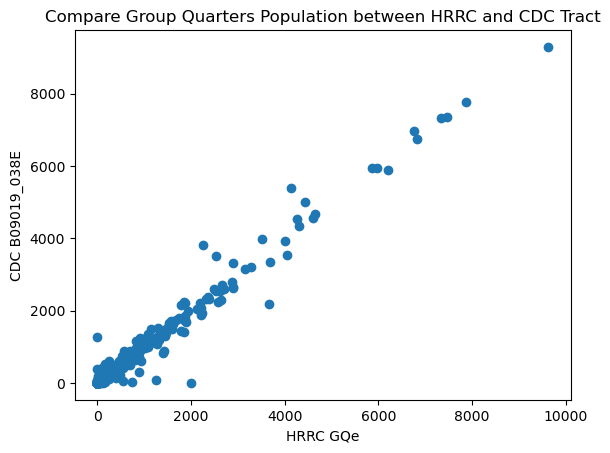

In [21]:
# scatter GQe and B09019_038E
import matplotlib.pyplot as plt
plt.scatter(check_gqpop_merge_df['Tract']['GQe'], check_gqpop_merge_df['Tract']['B09019_038E'])
plt.xlabel('HRRC GQe')
plt.ylabel('CDC B09019_038E')
plt.title('Compare Group Quarters Population between HRRC and CDC Tract')
plt.show()

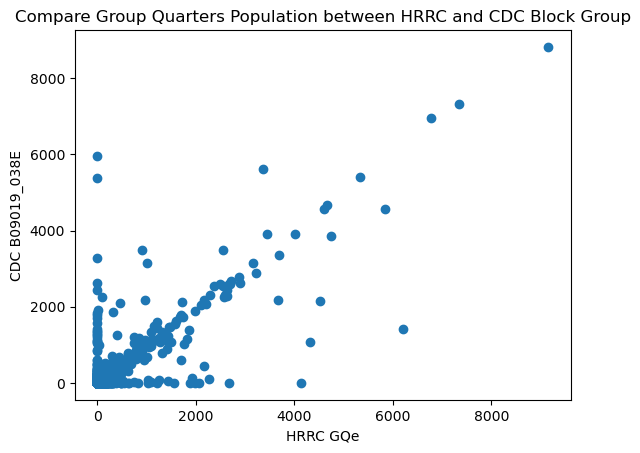

In [22]:
# scatter GQe and B09019_038E
import matplotlib.pyplot as plt
plt.scatter(check_gqpop_merge_df['BG']['GQe'], check_gqpop_merge_df['BG']['B09019_038E'])
plt.xlabel('HRRC GQe')
plt.ylabel('CDC B09019_038E')
plt.title('Compare Group Quarters Population between HRRC and CDC Block Group')
plt.show()

### Add SVI Quartiles

In [23]:
for file in ['BGTX','TractTX']:
    dfs[file] = my_utility.quartileSVI(dfs[file], 'SVIr', 'SVIr')
    dfs[file] = my_utility.quartileSVI(dfs[file], 'SVIp', 'SVIp')

    # Filling NA values with a placeholder (for example, a string 'NA') before comparison
    dfs[file]['SVIr_sviq'] = dfs[file]['SVIr_sviq'].astype(str).fillna('NA')
    dfs[file]['SVIp_sviq'] = dfs[file]['SVIp_sviq'].astype(str).fillna('NA')

    # create a new binary variable to check if SVIr_sviq and SVIp_sviq match
    dfs[file]['sviq_match'] = np.where(dfs[file]['SVIr_sviq'] == dfs[file]['SVIp_sviq'], 1, 0)
    # describe new variable
    dfs[file]['sviq_match'].describe()

    # replace svi_match with missing if SVI_scaled_TX_sviq or SVI_scaled_SETX_sviq is NA
    dfs[file]['sviq_match'] = \
        np.where(dfs[file]['SVIr_sviq'] == "<NA>", np.nan, dfs[file]['sviq_match'])
    dfs[file]['sviq_match'] = \
        np.where(dfs[file]['SVIp_sviq'] == "<NA>", np.nan, dfs[file]['sviq_match'])

In [24]:
dfs['BGTX']['sviq_match'].describe()

count    18497.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: sviq_match, dtype: float64

In [25]:
dfs['TractTX']['sviq_match'].describe()

count    6849.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: sviq_match, dtype: float64

In [26]:
dfs['BGTX'].head()

,OBJECTID,COUNTYFP,GEOID_BG,CZ,POPe,HHe,CHILDe,CHILDi,CHILDz,CHILDp,...,ELDERCAREc,TRANSNEEDc,SHELTNEEDc,CIVICCAPc,SVIc,Shape__Area,Shape__Length,SVIr_sviq,SVIp_sviq,sviq_match
0,1,48001,480019501001,475.0,1640,608,104,6.341,-0.046,0.547,...,4,4,4,5,5,2.124466e+07,25431.426373,4,4,1.0
1,2,48001,480019501002,475.0,1901,626,256,13.467,1.353,0.906,...,3,2,2,3,3,3.261917e+08,108560.446051,2,2,1.0
2,3,48001,480019501003,475.0,1417,545,63,4.446,-0.419,0.383,...,2,2,2,1,2,3.371185e+08,93125.623506,2,2,1.0
3,4,48001,480019504011,475.0,4867,81,34,0.699,-1.155,0.116,...,1,1,5,3,1,2.330774e+07,28412.793615,1,1,1.0
4,5,48001,480019504021,475.0,7335,0,0,0.000,-1.292,0.000,...,1,1,1,2,1,1.024178e+08,72910.047498,1,1,1.0


In [27]:
dfs['TractTX'].head()

,OBJECTID,COUNTYFP,GEOID_Tract,CZ,POPe,HHe,CHILDe,CHILDi,CHILDz,CHILDp,...,ELDERCAREc,TRANSNEEDc,SHELTNEEDc,CIVICCAPc,SVIc,Shape__Area,Shape__Length,SVIr_sviq,SVIp_sviq,sviq_match
0,1,48029,48029181703,69,7876,2832,314,3.987,-0.797,0.197,...,3,2,3,2,2,4.992877e+06,10077.600523,1,1,1.0
1,2,48029,48029181704,69,6472,1892,317,4.898,-0.532,0.305,...,3,4,3,4,4,7.609385e+06,12785.580711,3,3,1.0
2,3,48029,48029181705,69,6167,2412,691,11.205,1.298,0.904,...,1,4,3,3,4,5.946768e+06,10578.466881,3,3,1.0
3,4,48029,48029181711,69,8967,2825,209,2.331,-1.277,0.081,...,3,3,2,1,2,4.960805e+06,9307.749500,2,2,1.0
4,5,48029,48029181712,69,4471,1309,331,7.403,0.195,0.622,...,4,3,2,3,3,2.235500e+06,6584.875026,3,3,1.0


# Rename variables
Using the Variable Data Dictionary Excel Sheet rename the variables to match across SVI.

In [28]:
varmetadata_df.head(1)

,SVI,order,year,newvarname,gencat,gencatcode,comcat,comcatcode,theme,SVIcat,label,oldvarname,ACStable1v2,ACStable1v1,inverted,proportion,percent,dtype
0,CDC,10010,2018,C201810010,Geocode,100,TRACT2010,10,NaN,Geocode,Census Tract 11 Digit Geocode,FIPS,NaN,NaN,0,0,0,str


In [29]:
cleaned_files = my_utility.update_varnames(varmetadata_df= varmetadata_df,
                    svi_name = svi_name,
                    data_year = data_year,
                    merge_by_geo = dfs,
                    geoscales = ['TractTX','BGTX'],
                    programname = programname)

Current variable name:  GEOID_Tract
Found variable in variable dictionary
Then new variable name is:  TRACT2020 check length:  9
renaming GEOID_Tract to TRACT2020
Current variable name:  GEOID_BG
Found variable in variable dictionary
Then new variable name is:  BG2020 check length:  6
Could not find GEOID_BG in dataframe
Current variable name:  POPe
Found variable in variable dictionary
Then new variable name is:  H202010020 check length:  10
renaming POPe to H202010020
Current variable name:  HHe
Found variable in variable dictionary
Then new variable name is:  H202010030 check length:  10
renaming HHe to H202010030
Current variable name:  POPVi
Found variable in variable dictionary
Then new variable name is:  H202020010 check length:  10
renaming POPVi to H202020010
Current variable name:  ELDERHHPVi
Found variable in variable dictionary
Then new variable name is:  H202020012 check length:  10
renaming ELDERHHPVi to H202020012
Current variable name:  UNEMPi
Found variable in variable

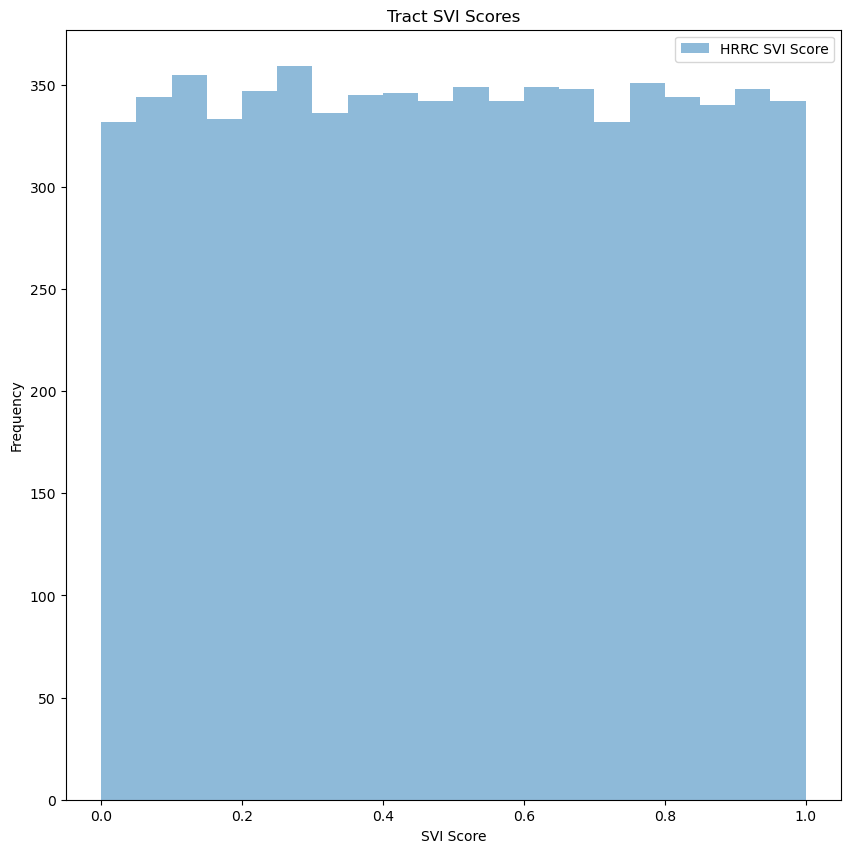

In [30]:
# check histogram for primary SVI var H202090012
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hist(cleaned_files['TractTX'][f'H{data_year}90012'], bins=20, alpha=0.5, label='HRRC SVI Score')
ax.set_xlabel('SVI Score')
ax.set_ylabel('Frequency')
ax.set_title('Tract SVI Scores')
ax.legend()


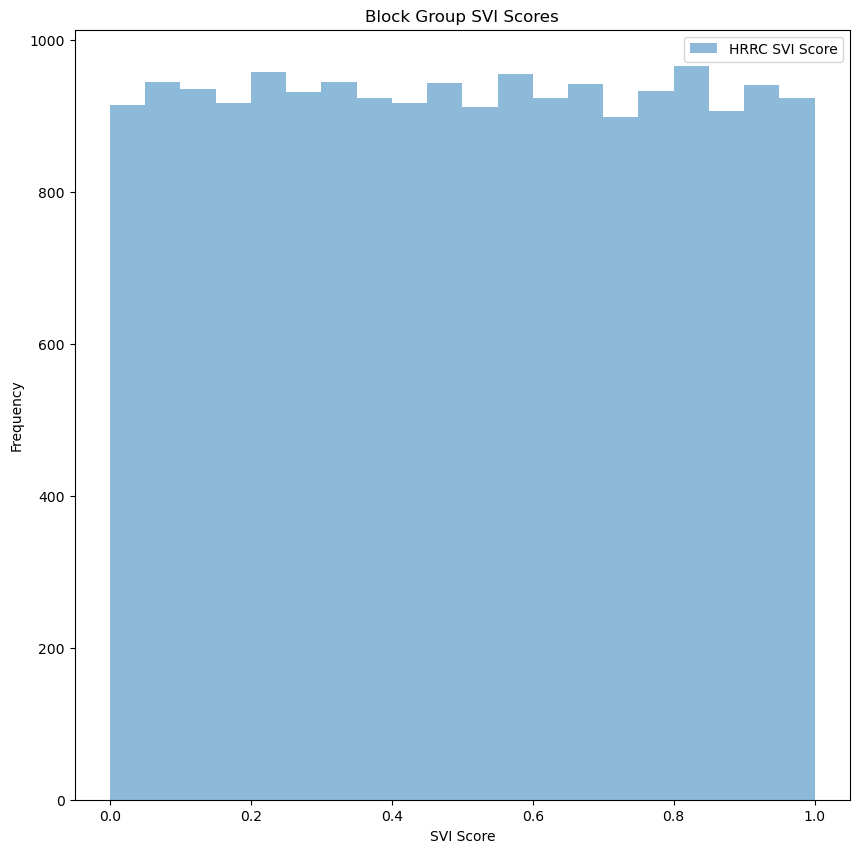

In [31]:
# check histogram for primary SVI var H202090012
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hist(cleaned_files['BGTX'][f'H{data_year}90012'], bins=20, alpha=0.5, label='HRRC SVI Score')
ax.set_xlabel('SVI Score')
ax.set_ylabel('Frequency')
ax.set_title('Block Group SVI Scores')
ax.legend()

In [32]:
cleaned_files['TractTX'].head()

,TRACT2020,H202010020,H202010030,H202020010,H202020012,H202020020,H202020040,H202021010,H202030011,H202033010,...,H202070040,H202070070,H202072010,H202072020,H202081011,H202090012,H202090093,H202091012,H202091093,H202092021
0,48029181703,7876,2832,0.12389,0.02684,0.01852,259500,0.06188,0.22952,0.08121,...,0.27788,0.88561,0.02295,0.00000,0.05473,0.224,0.341,1,1,1.0
1,48029181704,6472,1892,0.12268,0.03383,0.10427,148300,0.18451,0.22093,0.10307,...,0.14206,0.81232,0.05761,0.02808,0.09937,0.712,0.620,3,3,1.0
2,48029181705,6167,2412,0.11853,0.01285,0.05815,162900,0.07741,0.07131,0.15506,...,0.53673,0.48684,0.11111,0.01907,0.08997,0.669,0.593,3,3,1.0
3,48029181711,8967,2825,0.09892,0.05274,0.04339,182800,0.04458,0.17487,0.10796,...,0.20225,0.56915,0.01558,0.00594,0.03115,0.302,0.387,2,2,1.0
4,48029181712,4471,1309,0.06392,0.01910,0.05726,182300,0.12081,0.38732,0.08327,...,0.09701,0.91138,0.05195,0.00054,0.08709,0.608,0.559,3,3,1.0


In [33]:
cleaned_files['TractTX']['TRACT2020'].describe()

count            6884
unique           6884
top       48029181703
freq                1
Name: TRACT2020, dtype: object

In [34]:
cleaned_files['BGTX']['BG2020'].describe()

count            18626
unique           18626
top       480019501001
freq                 1
Name: BG2020, dtype: object